In [1]:
from random import uniform,randint

def generateNewValue(lim1, lim2):
   return randint(lim1, lim2)

def binToInt(x):
    val = 0
    # x.reverse()
    for bit in x:
        val = val * 2 + bit
    return val

In [2]:
from random import randint
class Chromosome:
    def __init__(self, problParam = None):
        self.__problParam = problParam
        self.__repres = [generateNewValue(problParam['min'], problParam['max']) for _ in range(problParam['noDim'])]
        self.__fitness = 0.0
    
    #reprezentarea cromozomului
    @property
    def repres(self):
        return self.__repres

    #functia de evaluare
    @property
    def fitness(self):
        return self.__fitness 
    
    @repres.setter
    def repres(self, l = []):
        self.__repres = l 
    
    @fitness.setter 
    def fitness(self, fit = 0.0):
        self.__fitness = fit 
    
    def crossover(self, c):
        #aleg o pozitie aleatoare
        r = randint(0, len(self.__repres) - 1)
        newrepres = []
        #primele r gene sunt luate din parintele 1
        for i in range(r):
            newrepres.append(self.__repres[i])
        #restul sunt luate din parintele 2
        for i in range(r, len(self.__repres)): 
            newrepres.append(c.__repres[i])
        #se creeaza descendentul cu aceasta combinatie de gene
        offspring = Chromosome(c.__problParam)
        offspring.repres = newrepres
        return offspring

    #aleg aleator o pozitie in cromozom si schimb valoarea cu una random
    def mutation(self):
        pos = randint(0, len(self.__repres) - 1)
        self.__repres[pos] = generateNewValue(self.__problParam['min'], self.__problParam['max'])
        
    def __str__(self):
        return '\nChromo: ' + str(self.__repres) + ' has fit: ' + str(self.__fitness)
    
    def __repr__(self):
        return self.__str__()
    
    def __eq__(self, c):
        return self.__repres == c.__repres and self.__fitness == c.__fitness

In [3]:
def readNet(fileName):
    f = open(fileName, "r")
    net = {}
    n = int(f.readline())
    net['noNodes'] = n
    mat = []
    for i in range(n):
        mat.append([])
        line = f.readline()
        elems = line.split(" ")
        for j in range(n):
            mat[-1].append(int(elems[j]))
    net["mat"] = mat 
    degrees = []
    noEdges = 0
    for i in range(n):
        d = 0
        for j in range(n):
            if (mat[i][j] == 1):
                d += 1
            if (j > i):
                noEdges += mat[i][j]
        degrees.append(d)
    net["noEdges"] = noEdges
    net["degrees"] = degrees
    f.close()
    return net

In [4]:
import networkx as nx

def load_gml_network_no_duplicates(file_path):
    # citeste manual toate muchiile, elimina duplicatele
    edges = set()
    nodes = set()

    with open(file_path, 'r') as f:
        for line in f:
            if "node [" in line or "edge [" in line:
                # Ignorăm liniile de noduri
                continue
            if "source" in line:
                source = int(line.strip().split()[-1])
                nodes.add(source)
            if "target" in line:
                target = int(line.strip().split()[-1])
                nodes.add(target)
                edge = tuple(sorted((source, target)))  # ordonat ca sa evitam duplicatele inversate
                edges.add(edge)

    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
    
    A = nx.to_numpy_array(G).astype(int)
    degrees = A.sum(axis=1).astype(int).tolist()
    net = {
        'graph': G,
        'mat': A.tolist(),
        'noNodes': G.number_of_nodes(),
        'noEdges': G.number_of_edges(),
        'degrees': degrees
    }
    return net


In [5]:
def load_gml_network(file_path):
    G_raw = nx.read_gml(file_path)
    G = nx.Graph(G_raw)  
    A = nx.to_numpy_array(G).astype(int)
    degrees = A.sum(axis=1).astype(int).tolist()

    return {
        'mat': A.tolist(),
        'noNodes': len(G.nodes),
        'graph': G,
        'degrees': degrees
    }

In [6]:
# evaluate the quality of previous communities inside a network
# https://www.cs.cmu.edu/~ckingsf/bioinfo-lectures/modularity.pdf

def modularity(communities, param):
    noNodes = param['noNodes']
    mat = param['mat']
    degrees = param['degrees']
    noEdges = param['noEdges']  
    M = 2 * noEdges #nr de muchii
    Q = 0.0
    #parcurg fiecare pereche de noduri, daca sunt in aceeeasi comunitate se calculeaza 
    #cat de conectate sunt-conexiunea asteptata daca muchiile sunt distribuite aleator
    for i in range(0, noNodes):
        for j in range(0, noNodes):
            if (communities[i] == communities[j]):
               Q += (mat[i][j] - degrees[i] * degrees[j] / M)
    #returnez suma normalizata
    return Q * 1 / M

#cat de densa e o comunitate
def internal_density(communities, param):
    from collections import defaultdict
    mat = param['mat']
    community_edges = defaultdict(int)  #nr de muchii interne
    community_nodes = defaultdict(set) #setul de noduri

    for i in range(len(communities)):
        comm = communities[i]
        #grupez nodurile pe comunitati
        community_nodes[comm].add(i)
        #calculez numarul de muchii interne
        for j in range(len(mat)):
            if communities[j] == comm and mat[i][j] == 1:
                community_edges[comm] += 1

    total_score = 0
    #calculez densitatea interna pt fiecare cumunitate (cate muchii exista raportat la maximul posibil)
    for comm in community_nodes:
        n = len(community_nodes[comm])
        e = community_edges[comm]
        if n > 1:
            total_score += e / (n * (n - 1))
    #returnez media densitatilor
    return total_score / len(community_nodes)

#masoara proportia de muchii care ies din comunitati fata de nr total de muchii externe
def cut_ratio(communities, param):
    mat = param['mat']
    from collections import defaultdict

    cut_edges = defaultdict(int)
    community_nodes = defaultdict(set)

    for i in range(len(communities)):
        comm = communities[i]
        community_nodes[comm].add(i)
        for j in range(len(mat)):
            if communities[j] != comm and mat[i][j] == 1:
                cut_edges[comm] += 1

    total_score = 0
    for comm in community_nodes:
        n = len(community_nodes[comm])
        if n > 0:
            # nr de muchii externe raportat la nr total posibil de muchii externe
            total_score += cut_edges[comm] / (n * (len(mat) - n))
    #valori apropiate de 0=>comunitati bine separate
    return total_score / len(community_nodes)


In [7]:
from random import choice,random

class GA:
    def __init__(self, net, pop_size, no_gen, no_communities, mutation_rate, fitness_func):
        self.net = net #reteaua 
        self.pop_size = pop_size #nr de cromozomi
        self.no_gen = no_gen #cate generatii ruleaza algoritmul
        self.no_communities = no_communities #numarul de comunitati
        self.mutation_rate = mutation_rate #probabilitatea de mutatie
        self.fitness_func = fitness_func #functia de evaluare a calitatii a unui cromozom
        problParam = {
            "noDim": net['noNodes'], #nr noduri din retea
            "min": 0,
            "max": no_communities - 1
        }#dictionar cu parametrii pt un cromozom
        self.population = [Chromosome(problParam) for _ in range(pop_size)] #populatia cu pop_siza cromozomi aleatori

    #calculeaza fitnessul folosind functia data
    def evaluate(self):
        for chrom in self.population:
            chrom.fitness = self.fitness_func(chrom.repres, self.net)

    #selecteaza aleator un cromozom din populatie
    def select(self):
        return choice(self.population)

    def run(self):
        self.evaluate()
        best = max(self.population, key=lambda x: x.fitness)#gaseste cel mai bun individ din populatie

        for gen in range(self.no_gen):
            next_gen = []
            #initializam generatia urmatoare
            while len(next_gen) < self.pop_size:
                #selectez 2 parinti aleatori
                p1, p2 = self.select(), self.select()
                #fac crossover intre ei
                child = p1.crossover(p2)
                #copilul sufera o mutatie
                if random() < self.mutation_rate:
                    child.mutation()
                #evaluam copilul si il adaugam in generatie
                child.fitness = self.fitness_func(child.repres, self.net)
                next_gen.append(child)
            #inlocuiesc populatia cu noua generatie
            self.population = next_gen
            #caut cel mai bun cromozom si daca e mai bun decat cel mai bun global, il salvam
            gen_best = max(self.population, key=lambda x: x.fitness)
            if gen_best.fitness > best.fitness:
                best = gen_best
           # print(f"Gen {gen} Best Fitness: {best.fitness:.4f}")
        #returnez cel mai bun cromozom
        return best

In [8]:
import community.community_louvain as community_louvain

def detect_communities_louvain(G):
    partition = community_louvain.best_partition(G)
    communities = [partition[i] for i in range(len(G.nodes))]
    return communities

In [9]:
import matplotlib.pyplot as plt
def draw_network(matrix):
    A = np.matrix(matrix)
    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G)
    plt.figure(figsize=(4, 4))
    nx.draw_networkx_nodes(G, pos, node_size=50, cmap=plt.cm.RdYlBu)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.title("Rețea fără comunități")
    plt.show()


In [10]:
def draw_communities(matrix, communities):
    A = np.matrix(matrix)
    G = nx.from_numpy_array(A)
    pos = nx.spring_layout(G)
    plt.figure(figsize=(4, 4))
    nx.draw_networkx_nodes(G, pos, node_size=50, cmap=plt.cm.RdYlBu, node_color=communities)
    nx.draw_networkx_edges(G, pos, alpha=0.3)
    plt.title("Rețea cu comunități")
    plt.show()

In [15]:
def run_detection(file_path, method, params=None):
    if file_path.endswith(".gml"):
        net = load_gml_network_no_duplicates(file_path)
        mat = nx.to_numpy_array(net['graph']).tolist()
    elif file_path.endswith(".in"):
        net = readNet(file_path)
        mat = net['mat']
    else:
        print(f"Format invalid pentru {file_path}")
        return

    draw_network(mat)

    if method == "predefined":
        print(f"\n== Louvain on {os.path.basename(file_path)} ==")
        G = nx.from_numpy_array(np.matrix(mat))
        partition = community_louvain.best_partition(G)
        communities = [partition[i] for i in range(len(G.nodes))]
        print("Detected communities:", communities)
        print("Number of communities:", len(set(communities)))
        draw_communities(mat, communities)
        print("\n==========================================\n ")

    elif method == "genetic":
        print(f"\n== Genetic Algorithm on {os.path.basename(file_path)} ==")
        pop_size = params.get("pop_size", 50)
        no_gen = params.get("no_gen", 100)
        k = params.get("k", 3)
        mut_rate = params.get("mut_rate", 0.1)
        fit_type = params.get("fitness", "modularity")
        
        if fit_type == "modularity":
            fitness_func = modularity  
        elif fit_type=="internal":
            fitness_func=internal_density
        else:
            fitness_func=cut_ratio

        ga = GA(net, pop_size, no_gen, k, mut_rate, fitness_func)
        best = ga.run()
        print("Best solution:", best.repres)
        print("Fitness ",fit_type,": ", best.fitness)
        print("Number of communities:", len(set(best.repres)))
        draw_communities(mat, best.repres)
        print("\n==========================================\n ")

        

    else:
        print("Unknown method:", method)


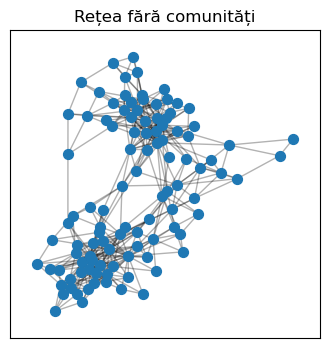


== Louvain on polbooks.gml ==
Detected communities: [0, 0, 0, 3, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 0, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 3, 4, 4, 3, 3, 3, 3, 2, 4, 1, 1, 1, 1, 1, 4, 4, 1, 4, 4, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 4]
Number of communities: 5


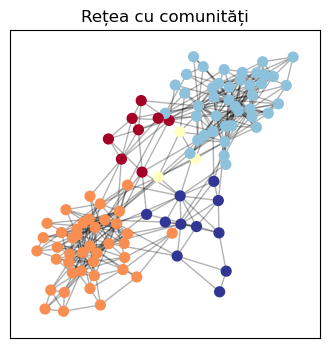

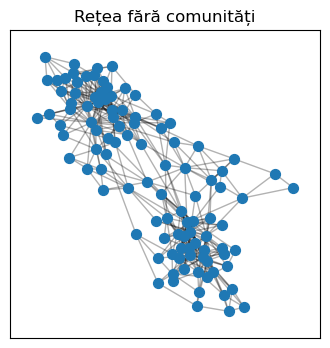


== Genetic Algorithm on polbooks.gml ==
Best solution: [3, 3, 4, 0, 3, 4, 1, 2, 0, 0, 4, 0, 0, 2, 2, 1, 4, 4, 3, 2, 2, 0, 3, 1, 0, 2, 3, 3, 0, 3, 1, 2, 3, 4, 1, 4, 3, 4, 1, 4, 2, 3, 2, 0, 0, 4, 4, 4, 2, 3, 4, 1, 2, 4, 0, 3, 2, 2, 3, 1, 1, 2, 1, 0, 0, 0, 1, 1, 3, 3, 4, 1, 2, 1, 2, 0, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 4, 2, 2, 1, 3, 1, 4, 0, 3, 2, 4, 1, 1, 3, 3, 3, 4, 4, 3]
Fitness  modularity :  0.054192954581681364
Number of communities: 5


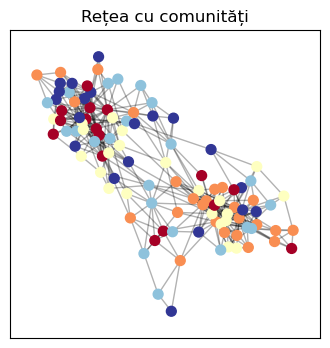

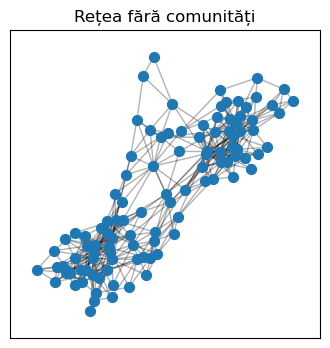


== Genetic Algorithm on polbooks.gml ==
Best solution: [2, 3, 2, 0, 4, 2, 3, 2, 1, 1, 0, 0, 1, 1, 0, 0, 0, 4, 4, 4, 1, 4, 2, 0, 4, 2, 0, 1, 2, 4, 3, 4, 3, 3, 3, 4, 3, 1, 2, 1, 3, 3, 4, 2, 2, 2, 1, 1, 0, 1, 4, 1, 3, 1, 3, 3, 1, 3, 1, 2, 3, 2, 2, 0, 3, 3, 3, 4, 3, 2, 3, 2, 2, 4, 1, 0, 2, 4, 1, 3, 1, 2, 4, 2, 3, 4, 2, 1, 3, 2, 3, 4, 4, 1, 4, 2, 1, 3, 1, 0, 2, 4, 3, 4, 3]
Fitness  internal :  0.11744730631687153
Number of communities: 5


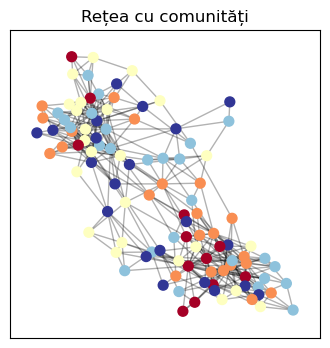

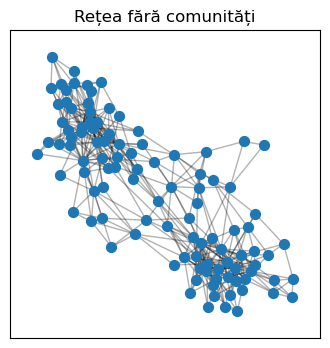


== Genetic Algorithm on polbooks.gml ==
Best solution: [0, 3, 4, 2, 4, 1, 0, 3, 2, 4, 0, 2, 1, 3, 0, 3, 2, 1, 3, 1, 0, 0, 1, 0, 3, 0, 3, 4, 0, 1, 1, 0, 1, 3, 3, 3, 4, 0, 4, 0, 1, 1, 3, 1, 0, 1, 3, 4, 3, 3, 0, 2, 0, 3, 3, 1, 1, 0, 3, 3, 1, 1, 0, 0, 0, 1, 2, 0, 3, 4, 3, 1, 2, 4, 4, 3, 0, 0, 3, 3, 1, 1, 3, 4, 4, 2, 2, 0, 3, 3, 4, 1, 0, 1, 3, 3, 4, 4, 0, 0, 3, 2, 1, 3, 3]
Fitness  cutratio :  0.09080183711486196
Number of communities: 5


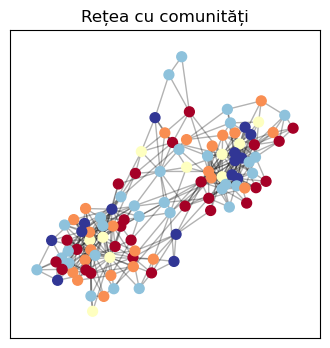

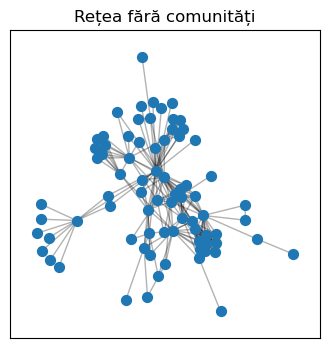


== Louvain on lesmiserables.gml ==
Detected communities: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 5, 3, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 0, 4, 5, 5, 3, 3, 5, 5, 5, 5, 5, 5, 5, 0, 4, 4, 4, 0, 5, 5, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 0, 2, 2, 4, 2]
Number of communities: 6


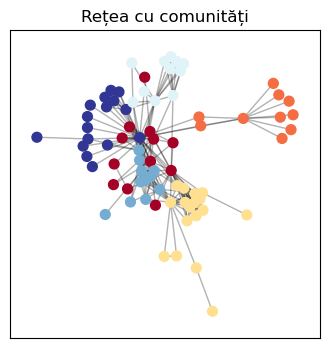

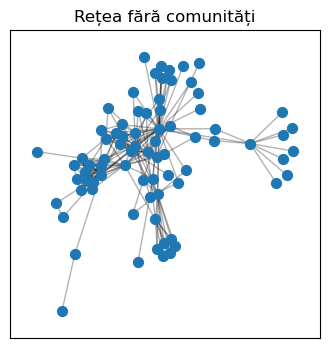


== Genetic Algorithm on lesmiserables.gml ==
Best solution: [3, 4, 3, 4, 0, 0, 3, 3, 0, 2, 6, 4, 4, 1, 0, 1, 3, 2, 0, 2, 6, 5, 2, 1, 1, 1, 3, 3, 2, 1, 6, 4, 1, 0, 1, 1, 4, 1, 6, 4, 5, 4, 0, 6, 0, 2, 4, 0, 0, 6, 6, 2, 5, 3, 6, 6, 6, 5, 3, 6, 1, 0, 0, 5, 5, 6, 5, 2, 1, 0, 1, 5, 3, 3, 5, 0, 1]
Fitness  modularity :  0.05109585219170413
Number of communities: 7


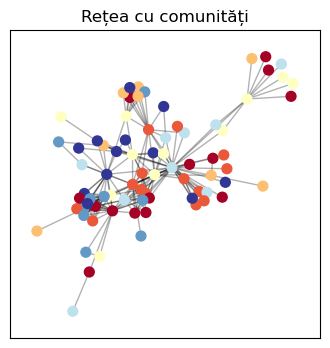

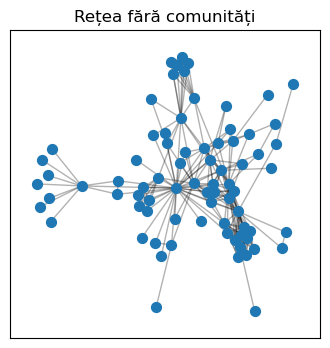


== Genetic Algorithm on lesmiserables.gml ==
Best solution: [3, 3, 3, 6, 4, 1, 0, 4, 5, 1, 3, 4, 5, 2, 1, 5, 1, 2, 3, 5, 2, 4, 3, 3, 3, 2, 6, 6, 1, 1, 4, 3, 4, 3, 1, 3, 2, 2, 3, 5, 4, 1, 4, 5, 4, 1, 5, 5, 1, 2, 2, 2, 5, 3, 5, 5, 1, 4, 6, 2, 1, 5, 0, 3, 5, 2, 4, 4, 6, 1, 6, 3, 4, 5, 6, 4, 0]
Fitness  internal :  0.138732695875553
Number of communities: 7


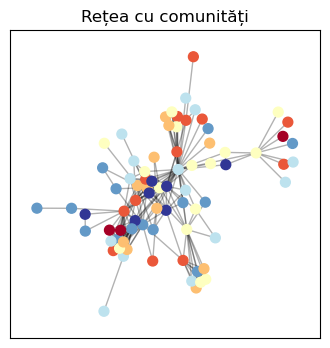

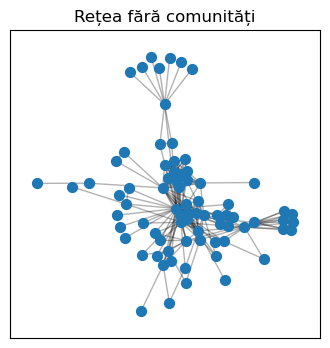


== Genetic Algorithm on lesmiserables.gml ==
Best solution: [2, 5, 3, 3, 6, 2, 6, 0, 0, 6, 3, 4, 1, 5, 3, 3, 0, 6, 0, 1, 1, 3, 2, 4, 6, 5, 2, 3, 6, 0, 0, 6, 1, 3, 2, 0, 1, 3, 4, 6, 2, 4, 0, 2, 2, 2, 0, 2, 4, 3, 0, 3, 6, 1, 2, 5, 3, 0, 0, 1, 5, 1, 1, 6, 5, 6, 2, 6, 1, 0, 6, 6, 3, 0, 2, 6, 4]
Fitness  cutratio :  0.10135791230998212
Number of communities: 7


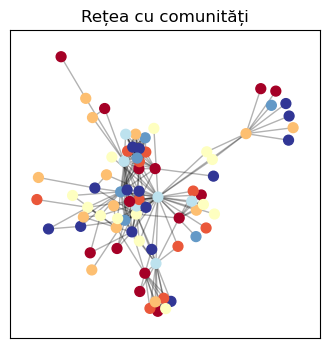

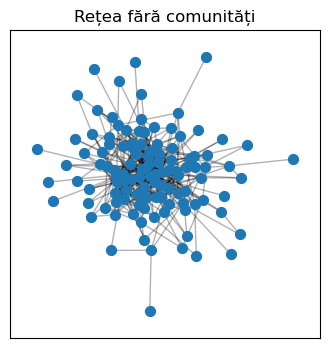


== Louvain on word_adjacencies.gml ==
Detected communities: [4, 4, 4, 4, 0, 0, 0, 5, 3, 3, 4, 6, 4, 1, 1, 5, 1, 2, 4, 6, 6, 4, 6, 1, 2, 5, 6, 6, 4, 1, 4, 2, 0, 5, 4, 3, 2, 1, 5, 3, 6, 4, 4, 6, 4, 4, 5, 1, 5, 1, 4, 4, 0, 4, 4, 0, 6, 5, 1, 1, 3, 3, 3, 6, 6, 2, 4, 2, 1, 6, 1, 3, 1, 4, 1, 5, 5, 5, 4, 6, 6, 6, 2, 2, 2, 4, 2, 2, 5, 0, 4, 4, 5, 4, 6, 5, 5, 4, 6, 0, 6, 3, 4, 2, 5, 1, 5, 5, 2, 6, 6, 4]
Number of communities: 7


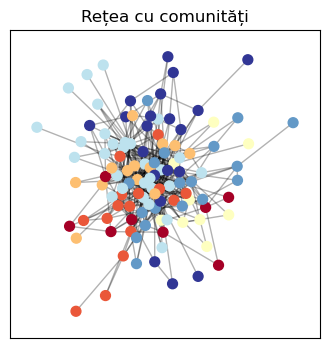

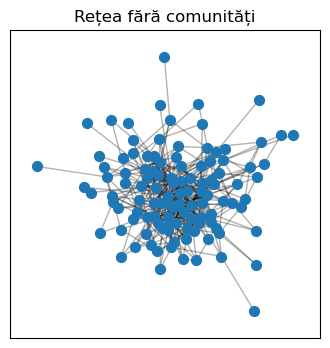


== Genetic Algorithm on word_adjacencies.gml ==
Best solution: [4, 5, 5, 1, 4, 1, 3, 1, 3, 0, 6, 3, 2, 1, 0, 0, 0, 6, 1, 5, 4, 5, 1, 0, 2, 0, 1, 1, 0, 6, 2, 2, 0, 3, 5, 3, 6, 6, 6, 3, 5, 1, 3, 1, 2, 6, 4, 4, 3, 4, 5, 4, 5, 1, 4, 6, 0, 6, 0, 4, 1, 3, 1, 0, 4, 4, 1, 0, 2, 0, 4, 4, 1, 4, 4, 5, 3, 5, 4, 1, 4, 0, 2, 0, 3, 1, 1, 4, 6, 6, 5, 4, 5, 5, 0, 3, 5, 4, 2, 2, 0, 6, 5, 4, 2, 3, 5, 3, 6, 5, 2, 5]
Fitness  modularity :  0.021973702422145372
Number of communities: 7


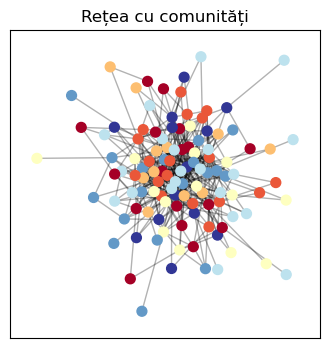

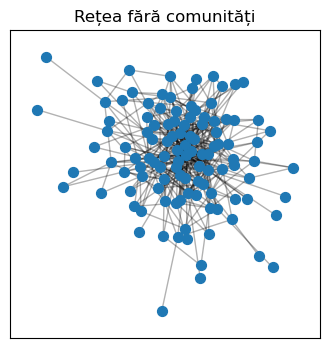


== Genetic Algorithm on word_adjacencies.gml ==
Best solution: [1, 5, 2, 1, 6, 6, 4, 1, 0, 6, 1, 6, 6, 6, 5, 5, 6, 4, 0, 3, 0, 0, 4, 5, 5, 1, 4, 3, 3, 1, 3, 2, 3, 3, 3, 2, 0, 0, 4, 6, 3, 6, 4, 0, 6, 1, 3, 5, 0, 4, 0, 2, 3, 0, 0, 0, 4, 4, 3, 1, 0, 6, 1, 1, 5, 0, 2, 4, 5, 0, 0, 5, 6, 4, 5, 1, 6, 6, 5, 6, 5, 5, 6, 6, 4, 1, 5, 1, 5, 0, 2, 0, 5, 5, 4, 1, 3, 4, 3, 5, 0, 0, 5, 5, 6, 1, 2, 6, 1, 6, 0, 1]
Fitness  internal :  0.11429887744571512
Number of communities: 7


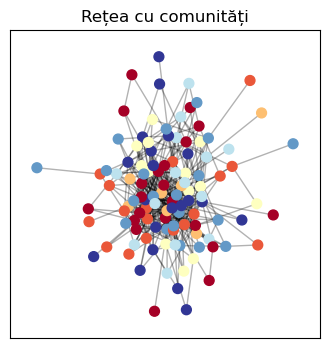

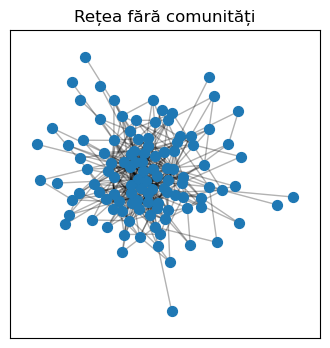


== Genetic Algorithm on word_adjacencies.gml ==
Best solution: [0, 6, 3, 5, 0, 2, 5, 5, 4, 2, 5, 5, 4, 0, 4, 2, 2, 1, 3, 6, 0, 3, 2, 1, 4, 1, 2, 6, 6, 4, 5, 2, 3, 5, 2, 3, 5, 0, 6, 2, 3, 2, 2, 0, 3, 2, 5, 4, 0, 3, 2, 6, 2, 4, 5, 5, 6, 4, 5, 0, 6, 2, 5, 1, 5, 2, 6, 5, 0, 5, 0, 4, 6, 4, 3, 6, 1, 5, 5, 2, 0, 6, 2, 5, 4, 3, 5, 5, 4, 4, 2, 5, 5, 6, 2, 6, 3, 3, 4, 0, 6, 6, 4, 2, 6, 0, 2, 3, 4, 4, 1, 0]
Fitness  cutratio :  0.0751599133048049
Number of communities: 7


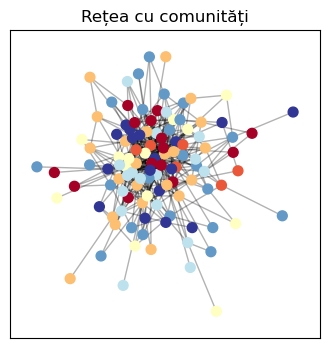

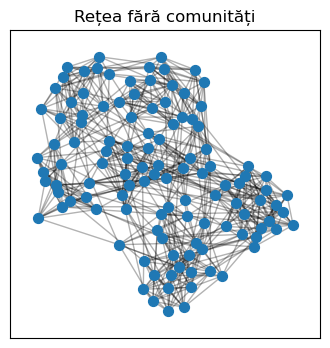


== Louvain on football.gml ==
Detected communities: [5, 1, 2, 3, 5, 3, 2, 4, 4, 5, 3, 5, 6, 2, 6, 2, 5, 7, 6, 8, 7, 4, 4, 5, 5, 1, 6, 7, 5, 8, 8, 6, 2, 1, 6, 8, 6, 1, 6, 2, 3, 5, 6, 6, 0, 1, 9, 2, 0, 9, 5, 4, 3, 9, 6, 8, 7, 0, 7, 7, 2, 6, 7, 7, 2, 7, 0, 9, 4, 5, 7, 6, 3, 9, 3, 0, 7, 4, 4, 8, 8, 3, 8, 9, 3, 6, 0, 7, 9, 1, 5, 0, 0, 5, 8, 7, 7, 7, 3, 6, 2, 8, 3, 1, 5, 1, 2, 3, 4, 1, 9, 4, 0, 7, 9]
Number of communities: 10


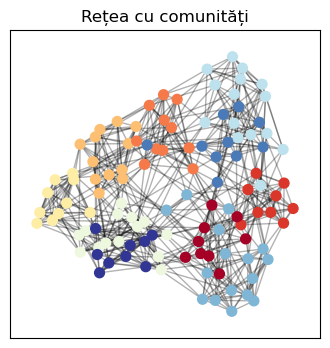

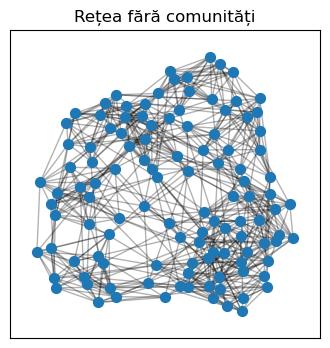


== Genetic Algorithm on football.gml ==
Best solution: [9, 4, 2, 9, 1, 1, 9, 7, 5, 8, 6, 0, 2, 2, 6, 4, 9, 5, 2, 0, 1, 0, 0, 0, 8, 6, 2, 4, 9, 7, 5, 5, 6, 0, 3, 8, 0, 7, 9, 7, 7, 0, 0, 7, 6, 9, 6, 2, 1, 6, 7, 7, 8, 1, 3, 3, 3, 4, 4, 0, 2, 8, 3, 4, 4, 5, 6, 4, 1, 3, 1, 0, 6, 4, 1, 9, 0, 4, 5, 2, 9, 6, 8, 0, 1, 9, 1, 3, 5, 4, 5, 1, 5, 6, 5, 1, 2, 9, 6, 0, 1, 0, 1, 0, 8, 7, 7, 6, 7, 9, 6, 4, 1, 9, 5]
Fitness  modularity :  0.027651296408165844
Number of communities: 10


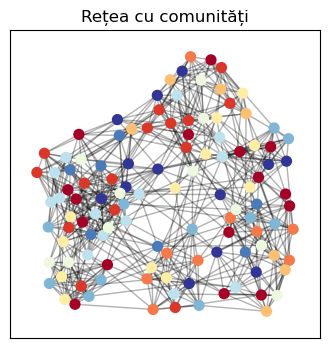

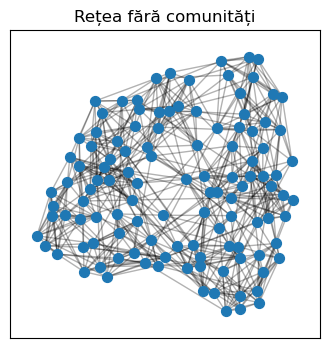


== Genetic Algorithm on football.gml ==
Best solution: [9, 2, 5, 3, 5, 8, 1, 2, 7, 3, 5, 2, 4, 0, 8, 7, 1, 9, 6, 8, 5, 7, 1, 7, 9, 9, 7, 1, 5, 5, 6, 3, 0, 5, 2, 9, 2, 1, 3, 1, 8, 5, 7, 6, 1, 2, 9, 8, 7, 9, 3, 5, 3, 1, 2, 3, 5, 8, 8, 2, 1, 7, 4, 3, 2, 7, 7, 6, 5, 4, 4, 7, 9, 6, 8, 9, 4, 7, 8, 8, 6, 4, 3, 6, 1, 5, 7, 9, 8, 1, 7, 2, 3, 1, 5, 4, 5, 2, 7, 1, 8, 2, 2, 1, 4, 9, 1, 1, 6, 8, 5, 2, 8, 9, 5]
Fitness  internal :  0.20150155400155398
Number of communities: 10


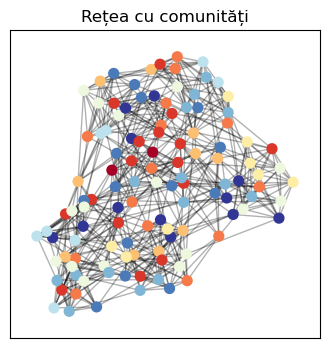

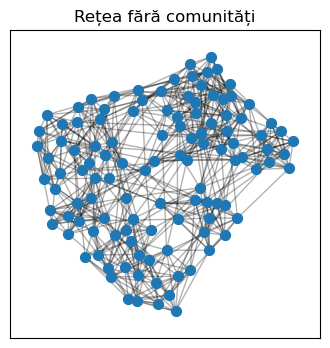


== Genetic Algorithm on football.gml ==
Best solution: [5, 0, 3, 1, 2, 1, 5, 6, 3, 6, 7, 2, 0, 4, 4, 7, 8, 2, 4, 6, 3, 0, 8, 9, 6, 3, 5, 9, 4, 5, 2, 6, 6, 9, 6, 7, 9, 3, 3, 8, 9, 7, 1, 2, 2, 1, 0, 2, 9, 7, 6, 2, 2, 2, 0, 3, 9, 9, 8, 4, 9, 4, 0, 7, 5, 5, 6, 3, 4, 5, 9, 7, 6, 0, 4, 0, 0, 8, 1, 2, 6, 0, 6, 1, 9, 0, 1, 2, 6, 0, 8, 1, 3, 8, 3, 2, 9, 9, 1, 9, 1, 6, 8, 4, 4, 4, 0, 8, 7, 5, 8, 5, 4, 7, 2]
Fitness  cutratio :  0.09648545197363427
Number of communities: 10


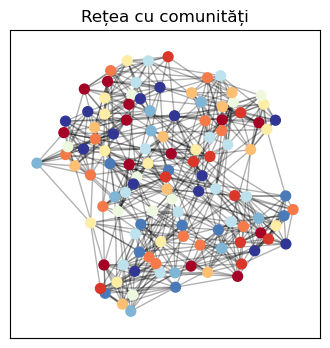

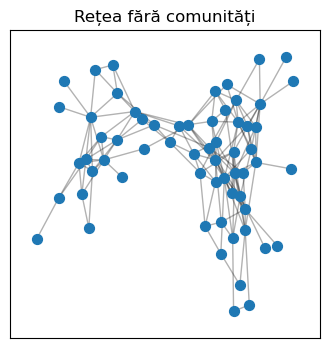


== Louvain on dolphins.gml ==
Detected communities: [0, 1, 0, 4, 3, 1, 1, 0, 4, 1, 0, 3, 2, 1, 2, 3, 2, 1, 3, 0, 2, 3, 1, 3, 3, 1, 1, 1, 4, 3, 0, 1, 1, 2, 2, 3, 4, 2, 2, 4, 2, 1, 0, 2, 2, 3, 2, 0, 1, 2, 2, 3, 2, 2, 1, 3, 1, 1, 2, 4, 1, 2]
Number of communities: 5


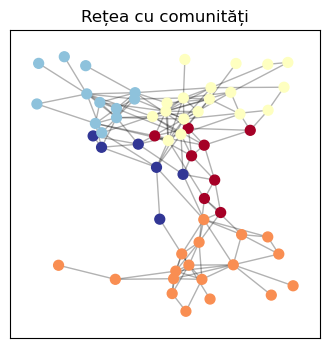

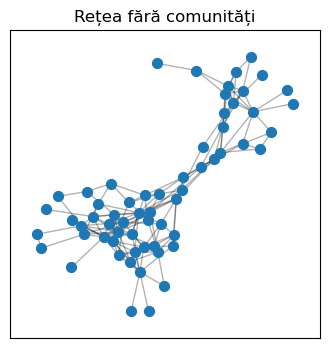


== Genetic Algorithm on dolphins.gml ==
Best solution: [1, 1, 3, 1, 0, 4, 4, 3, 0, 4, 1, 0, 0, 4, 1, 0, 1, 3, 2, 1, 3, 4, 4, 0, 2, 4, 3, 4, 2, 0, 3, 0, 4, 1, 2, 1, 3, 3, 1, 3, 3, 2, 2, 2, 3, 4, 2, 3, 3, 3, 1, 0, 1, 4, 0, 2, 2, 4, 2, 1, 4, 4]
Fitness  modularity :  0.09226296428147651
Number of communities: 5


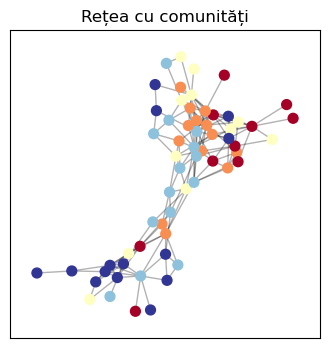

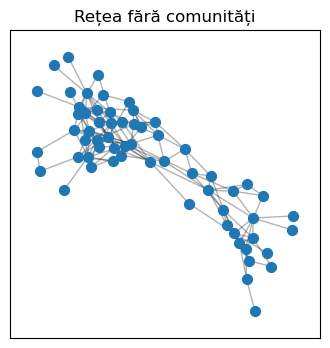


== Genetic Algorithm on dolphins.gml ==
Best solution: [4, 1, 4, 1, 0, 4, 0, 4, 0, 4, 1, 2, 0, 4, 3, 2, 1, 4, 0, 2, 1, 0, 1, 2, 4, 4, 4, 0, 4, 0, 0, 1, 2, 3, 2, 1, 1, 1, 1, 2, 2, 4, 2, 1, 0, 4, 2, 1, 0, 1, 0, 2, 2, 0, 2, 4, 0, 4, 2, 2, 0, 2]
Fitness  internal :  0.2703663003663004
Number of communities: 5


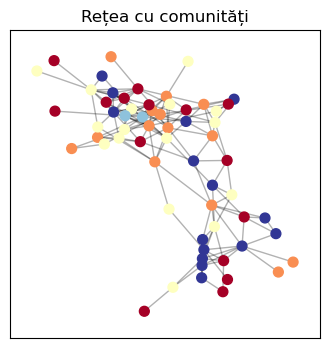

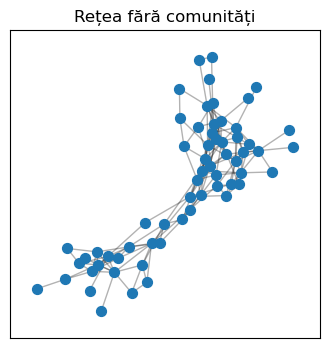


== Genetic Algorithm on dolphins.gml ==
Best solution: [3, 2, 4, 0, 3, 1, 3, 4, 3, 0, 0, 0, 1, 4, 2, 4, 0, 3, 2, 1, 1, 1, 3, 0, 0, 1, 0, 4, 0, 1, 0, 4, 0, 3, 3, 3, 2, 2, 1, 1, 3, 3, 4, 0, 0, 2, 4, 2, 3, 1, 0, 4, 4, 1, 0, 1, 4, 2, 4, 4, 1, 3]
Fitness  cutratio :  0.09562976509025142
Number of communities: 5


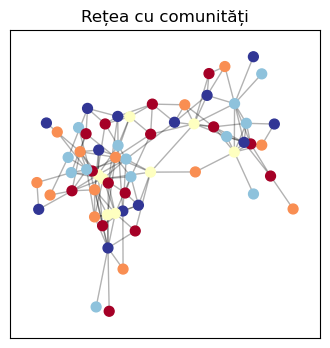

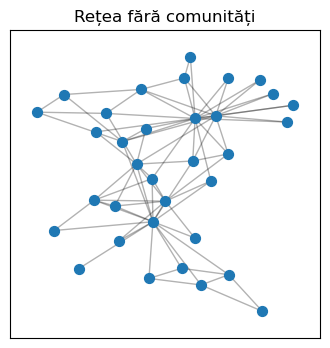


== Louvain on karate.gml ==
Detected communities: [1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 2, 2, 2, 0, 2, 2, 0, 0, 2, 0, 0]
Number of communities: 4


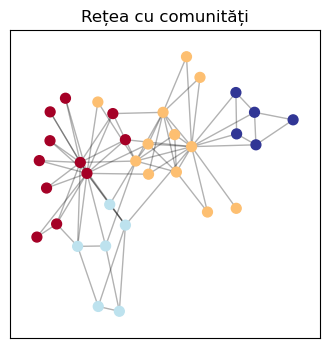

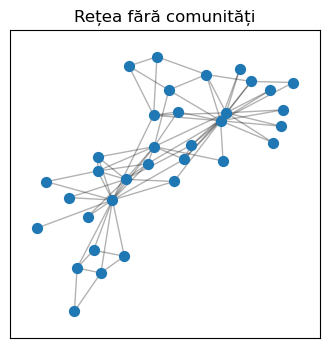


== Genetic Algorithm on karate.gml ==
Best solution: [2, 0, 0, 0, 0, 2, 1, 3, 3, 2, 2, 1, 1, 0, 2, 3, 2, 3, 1, 1, 1, 3, 1, 3, 3, 2, 3, 3, 0, 3, 0, 3, 3, 3]
Fitness  modularity :  0.0762656147271534
Number of communities: 4


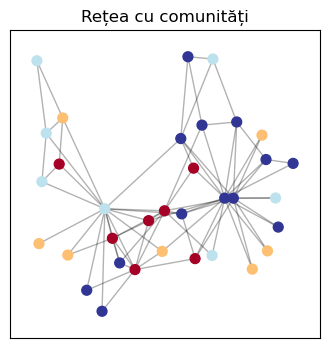

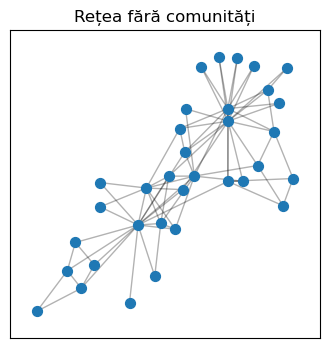


== Genetic Algorithm on karate.gml ==
Best solution: [0, 0, 0, 0, 3, 3, 1, 0, 3, 3, 2, 1, 3, 2, 1, 1, 3, 2, 2, 1, 1, 3, 2, 3, 1, 3, 2, 2, 2, 2, 3, 3, 3, 3]
Fitness  internal :  0.3018162393162393
Number of communities: 4


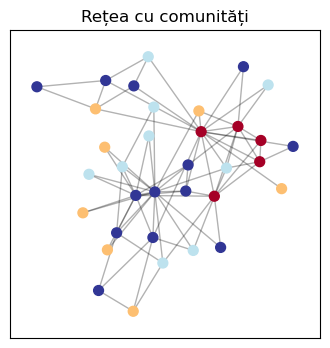

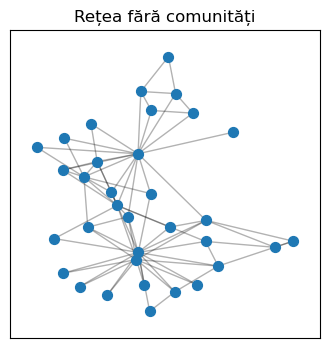


== Genetic Algorithm on karate.gml ==
Best solution: [0, 2, 1, 3, 1, 3, 1, 1, 2, 0, 1, 3, 1, 1, 1, 1, 1, 1, 3, 1, 2, 1, 3, 3, 3, 2, 2, 2, 3, 1, 3, 1, 1, 2]
Fitness  cutratio :  0.18854993386243385
Number of communities: 4


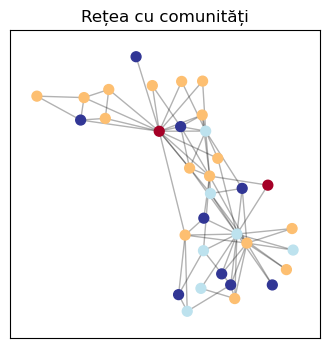

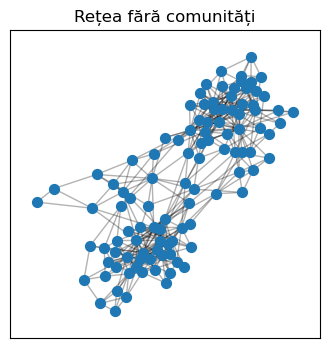


== Louvain on krebs.gml ==
Detected communities: [0, 0, 0, 3, 0, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 3, 4, 4, 3, 3, 3, 3, 1, 4, 2, 2, 2, 2, 2, 4, 4, 2, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4]
Number of communities: 5


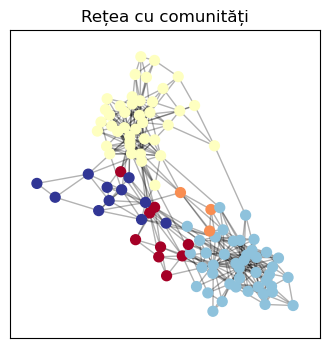

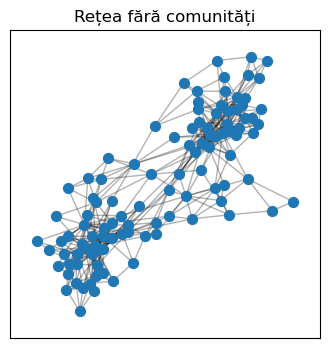


== Genetic Algorithm on krebs.gml ==
Best solution: [1, 2, 1, 1, 2, 1, 1, 3, 1, 2, 1, 0, 1, 2, 3, 1, 1, 3, 0, 1, 3, 0, 0, 1, 3, 0, 3, 3, 1, 1, 3, 0, 1, 1, 1, 1, 2, 2, 0, 0, 2, 3, 2, 3, 2, 0, 1, 1, 0, 3, 0, 0, 1, 2, 3, 1, 2, 2, 0, 2, 3, 2, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 3, 3, 0, 3, 1, 2, 0, 3, 3, 3, 0, 2, 1, 2, 0, 1, 0, 1, 2, 3, 3, 2, 0, 2, 2, 2, 1, 2, 2, 2, 0]
Fitness  modularity :  0.04088317110668884
Number of communities: 4


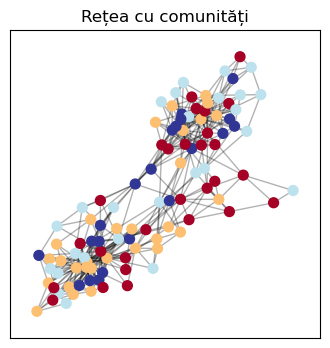

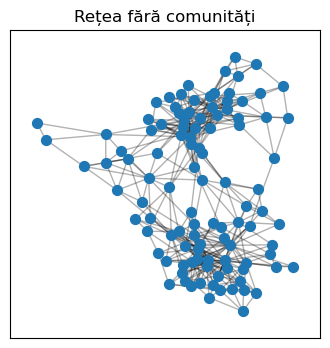


== Genetic Algorithm on krebs.gml ==
Best solution: [2, 0, 2, 0, 2, 0, 3, 2, 3, 0, 3, 3, 0, 3, 0, 2, 3, 3, 0, 3, 1, 3, 0, 1, 1, 0, 2, 1, 3, 2, 1, 2, 0, 1, 1, 1, 2, 3, 1, 0, 1, 0, 0, 0, 3, 0, 3, 2, 2, 0, 2, 0, 3, 2, 0, 2, 2, 0, 2, 2, 1, 0, 0, 2, 3, 0, 3, 0, 2, 1, 3, 1, 3, 1, 2, 3, 0, 2, 3, 0, 2, 1, 1, 0, 0, 2, 3, 2, 0, 2, 3, 0, 0, 2, 3, 0, 0, 3, 1, 2, 0, 0, 3, 3, 0]
Fitness  internal :  0.10077048768225239
Number of communities: 4


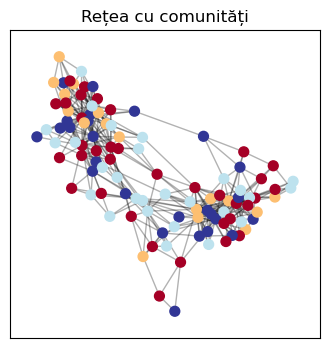

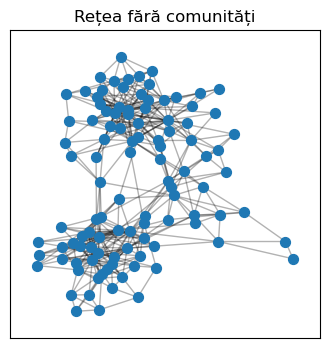


== Genetic Algorithm on krebs.gml ==
Best solution: [0, 0, 1, 2, 2, 0, 3, 3, 2, 3, 0, 3, 3, 0, 0, 3, 3, 0, 0, 0, 3, 3, 0, 1, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0, 3, 3, 3, 2, 0, 3, 0, 3, 1, 1, 1, 0, 2, 0, 2, 0, 2, 1, 1, 1, 1, 2, 0, 3, 0, 0, 0, 3, 0, 3, 0, 3, 1, 3, 0, 0, 2, 0, 0, 1, 1, 3, 3, 1, 0, 2, 3, 0, 2, 2, 2, 2, 1, 3, 0, 0, 0, 0, 0, 1, 0, 3, 3, 3, 0, 3, 3, 1, 0, 0]
Fitness  cutratio :  0.0891941789962444
Number of communities: 4


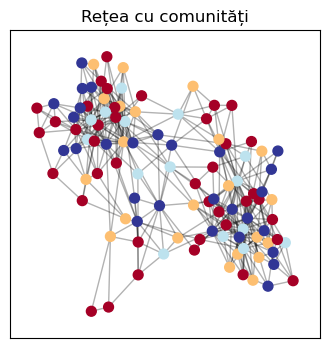

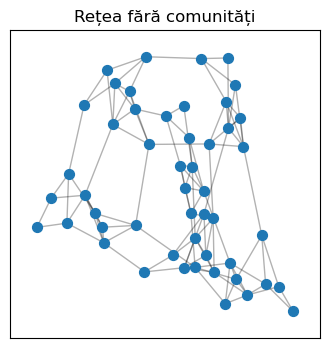


== Louvain on academiccolab.gml ==
Detected communities: [0, 1, 2, 3, 4, 5, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5]
Number of communities: 6


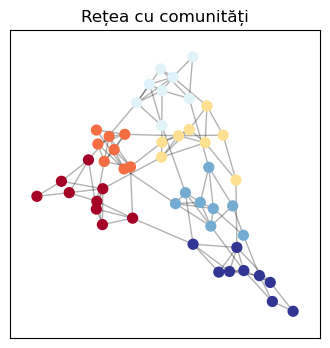

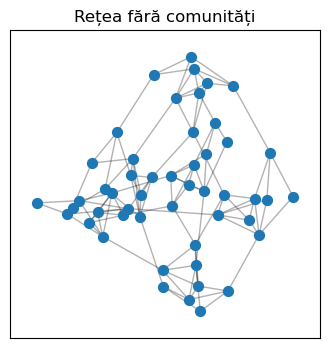


== Genetic Algorithm on academiccolab.gml ==
Best solution: [5, 5, 5, 5, 5, 0, 2, 5, 0, 0, 5, 3, 3, 3, 5, 5, 3, 4, 4, 4, 1, 0, 2, 4, 3, 2, 2, 0, 5, 0, 0, 2, 2, 1, 3, 5, 4, 5, 5, 3, 1, 1, 2, 4, 0, 1, 4, 3, 3, 3]
Fitness  modularity :  0.10780991735537189
Number of communities: 6


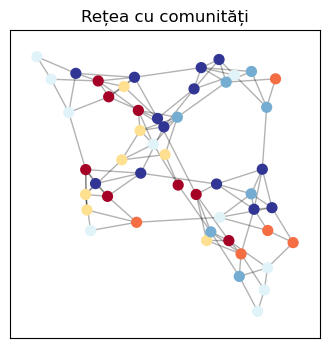

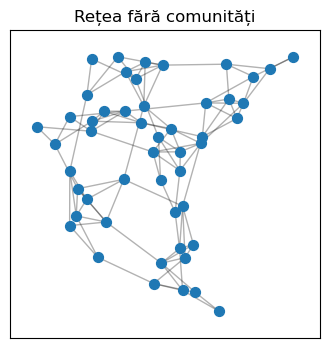


== Genetic Algorithm on academiccolab.gml ==
Best solution: [4, 2, 5, 3, 1, 4, 2, 5, 4, 1, 4, 5, 5, 0, 1, 1, 4, 4, 5, 5, 3, 5, 2, 4, 5, 2, 0, 5, 4, 3, 3, 1, 1, 3, 5, 2, 1, 3, 2, 1, 4, 5, 0, 0, 5, 0, 1, 5, 4, 5]
Fitness  internal :  0.16282051282051282
Number of communities: 6


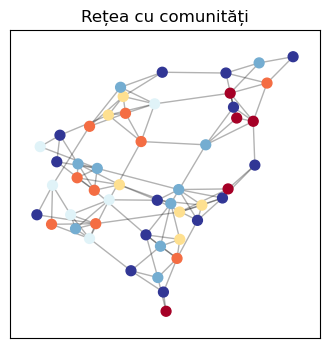

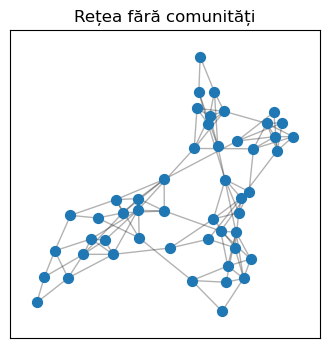


== Genetic Algorithm on academiccolab.gml ==
Best solution: [5, 0, 3, 5, 3, 0, 3, 4, 1, 0, 1, 0, 2, 0, 5, 1, 4, 5, 2, 3, 0, 3, 2, 0, 1, 3, 4, 3, 3, 4, 1, 5, 3, 4, 3, 5, 4, 5, 1, 5, 2, 0, 1, 5, 4, 4, 3, 2, 3, 5]
Fitness  cutratio :  0.10220959375182141
Number of communities: 6


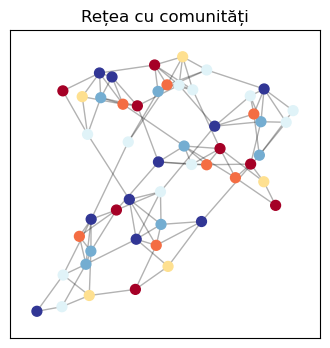

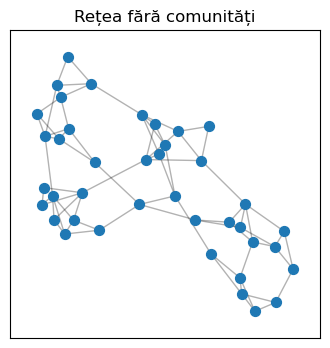


== Louvain on corporatenetwork.gml ==
Detected communities: [0, 1, 0, 2, 4, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3]
Number of communities: 5


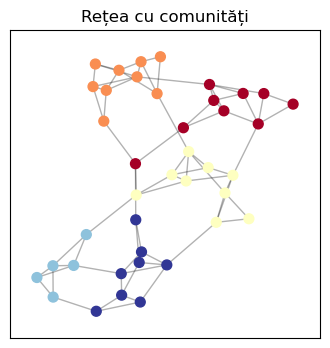

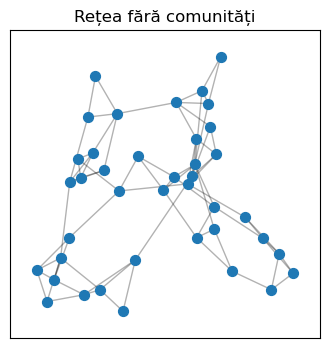


== Genetic Algorithm on corporatenetwork.gml ==
Best solution: [0, 0, 1, 0, 3, 4, 2, 2, 4, 3, 4, 1, 4, 3, 3, 2, 0, 0, 3, 3, 0, 0, 3, 1, 1, 3, 1, 2, 3, 4, 3, 4, 4, 2, 4, 4, 2, 0, 0, 1]
Fitness  modularity :  0.0749634769905041
Number of communities: 5


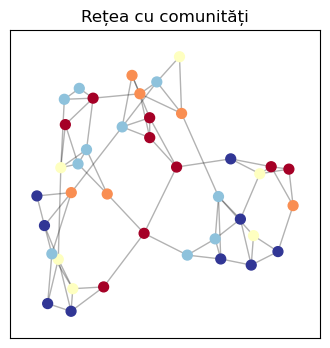

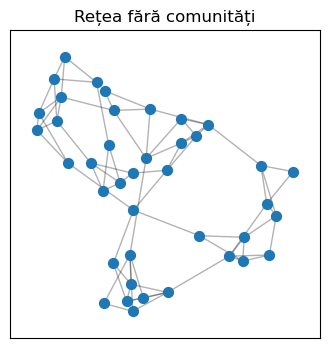


== Genetic Algorithm on corporatenetwork.gml ==
Best solution: [1, 1, 0, 1, 0, 0, 0, 3, 3, 4, 1, 0, 3, 3, 3, 1, 0, 0, 4, 0, 1, 1, 0, 3, 1, 3, 0, 4, 4, 0, 2, 2, 4, 1, 0, 4, 1, 1, 0, 3]
Fitness  internal :  0.2525607725607726
Number of communities: 5


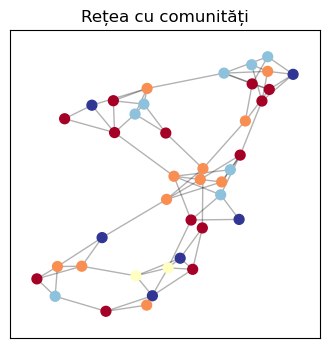

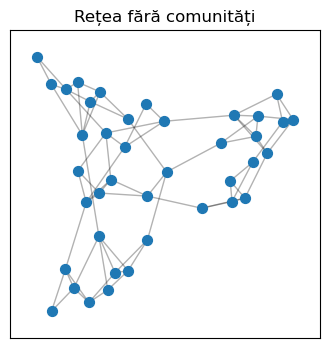


== Genetic Algorithm on corporatenetwork.gml ==
Best solution: [4, 4, 3, 1, 1, 1, 0, 3, 4, 0, 4, 2, 0, 0, 2, 4, 2, 4, 2, 1, 1, 4, 0, 4, 3, 1, 0, 4, 3, 1, 2, 4, 4, 1, 3, 4, 2, 3, 1, 0]
Fitness  cutratio :  0.11002201467097103
Number of communities: 5


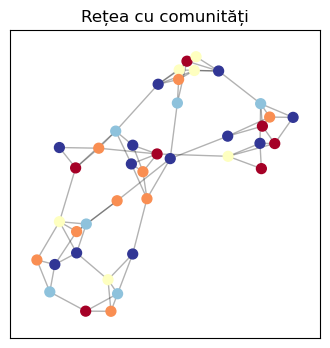

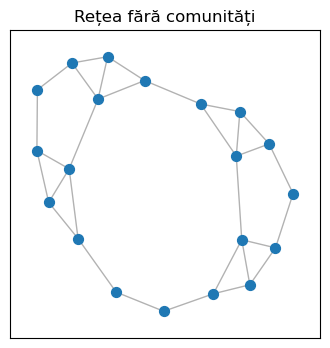


== Louvain on socialnetwork.gml ==
Detected communities: [0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 2, 2, 2, 2, 3]
Number of communities: 4


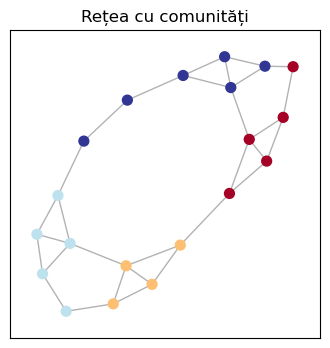

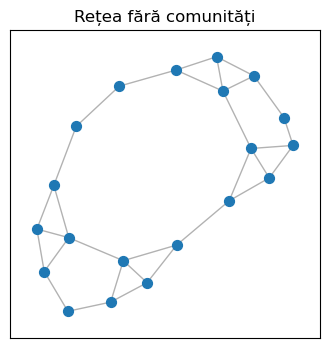


== Genetic Algorithm on socialnetwork.gml ==
Best solution: [3, 0, 0, 0, 0, 4, 4, 2, 2, 2, 2, 1, 0, 4, 4, 2, 2, 1, 1, 3]
Fitness  modularity :  0.1688888888888889
Number of communities: 5


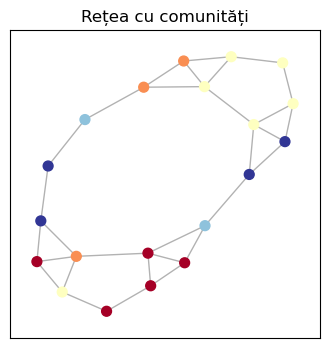

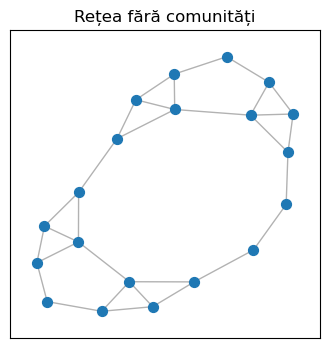


== Genetic Algorithm on socialnetwork.gml ==
Best solution: [1, 1, 2, 4, 0, 1, 1, 1, 4, 4, 0, 3, 3, 2, 2, 1, 2, 1, 2, 4]
Fitness  internal :  0.5304761904761904
Number of communities: 5


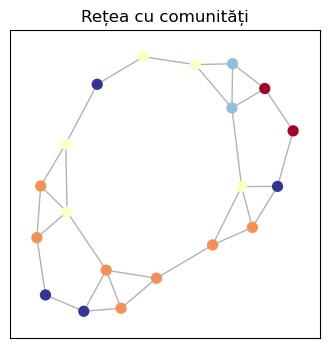

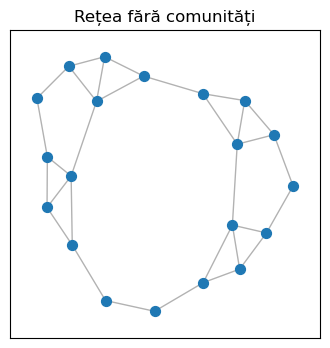


== Genetic Algorithm on socialnetwork.gml ==
Best solution: [4, 0, 2, 1, 0, 0, 1, 4, 3, 4, 1, 4, 0, 4, 1, 2, 3, 1, 4, 2]
Fitness  cutratio :  0.18636753034547152
Number of communities: 5


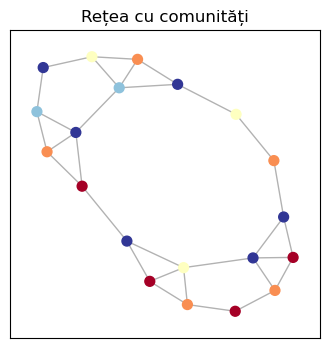

In [16]:
import os
import numpy as np

def main():
    datasets = [
        ("data/polbooks.gml", "predefined", {}),
        ("data/polbooks.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 5, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/polbooks.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/polbooks.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.05, "fitness": "cutratio"}),
        ("data/lesmiserables.gml", "predefined", {}),
        ("data/lesmiserables.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 7, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/lesmiserables.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 7, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/lesmiserables.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 7, "mut_rate": 0.05, "fitness": "cutratio"}),
        ("data/word_adjacencies.gml", "predefined", {}),
        ("data/word_adjacencies.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 7, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/word_adjacencies.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 7, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/word_adjacencies.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 7, "mut_rate": 0.05, "fitness": "cutratio"}),
        ("data/football.gml", "predefined", {}),
        ("data/football.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 10, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/football.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 10, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/football.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 10, "mut_rate": 0.05, "fitness": "cutratio"}),
        ("data/dolphins.gml", "predefined", {}),
        ("data/dolphins.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 5, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/dolphins.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.1, "fitness": "internal"}),
        ("data/dolphins.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.1, "fitness": "cutratio"}),
        ("data/karate.gml", "predefined", {}),
        ("data/karate.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 4, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/karate.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 4, "mut_rate": 0.1, "fitness": "internal"}),
        ("data/karate.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 4, "mut_rate": 0.1, "fitness": "cutratio"}),
        ("data/krebs.gml", "predefined", {}),
        ("data/krebs.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 4, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/krebs.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 4, "mut_rate": 0.1, "fitness": "internal"}),
        ("data/krebs.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 4, "mut_rate": 0.1, "fitness": "cutratio"}),
        ("data/academiccolab.gml", "predefined", {}),
        ("data/academiccolab.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 6, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/academiccolab.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 6, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/academiccolab.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 6, "mut_rate": 0.05, "fitness": "cutratio"}),
        ("data/corporatenetwork.gml", "predefined", {}),
        ("data/corporatenetwork.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 5, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/corporatenetwork.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/corporatenetwork.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.05, "fitness": "cutratio"}),
        ("data/socialnetwork.gml", "predefined", {}),
        ("data/socialnetwork.gml", "genetic", {"pop_size": 30, "no_gen": 100, "k": 5, "mut_rate": 0.05, "fitness": "modularity"}),
        ("data/socialnetwork.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.05, "fitness": "internal"}),
        ("data/socialnetwork.gml", "genetic", {"pop_size": 50, "no_gen": 150, "k": 5, "mut_rate": 0.05, "fitness": "cutratio"}),
        
    ]

    for file_path, method, params in datasets:
        run_detection(file_path, method, params)

if __name__ == "__main__":
    main()
